In [419]:
## analyze data saved with the lab jack
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import scipy.signal as sp
from scipy.optimize import curve_fit

In [380]:
### first, compare PSDs for some data set (curr_files) to some ref set (ref_files)

data_dir = "C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250317/"

## Files for 1-50 Hz noise drive
curr_files = glob(data_dir + "transfer_func_data_noise_0.100Hz_20.000V_5.57e-07mbar.npz")
ref_files = glob(data_dir + "transfer_func_data_noise_0.100Hz_0.002V_5.57e-07mbar.npz")

# ## Compare 1-50 Hz and 0.5-25 Hz drive
# curr_files = glob(data_dir + "transfer_func_data_noise_0.100Hz_20.000V*.npz")
# ref_files = glob(data_dir + "transfer_func_data_noise_0.050Hz_20.000V*.npz")

nperseg = 2**14

channel_list = ['x', 'y', 'Sum', 'Drive']

print("Found %d current files and %d reference files" % (len(curr_files), len(ref_files)))

Found 1 current files and 1 reference files


In [381]:
def make_psd_from_file_list(files):
    psd_dict = {}
    n_psds = 0

    for ch in channel_list:
        psd_dict[ch] = None

    for f in files:
        data = np.load(f)

        curr_pressures = data['pressure_data']
        #print("Start/End pressures: %.2e, %.2e" % (curr_pressures[0], curr_pressures[-1]))
    
        for meas in range(len(data['data'])):
            curr_data = data['data'][meas]

            ## ignore the file if the y data drifted out of range
            if(np.abs(np.median(curr_data[:, 1])) > 3):
                #print("Skipping trace for file %s, y data drifted out of range" % f)
                continue

            n_psds += 1

            for ch_idx, ch in enumerate(channel_list):
                freqs, cpsd = sp.welch(curr_data[:,ch_idx], nperseg=nperseg, fs=data['Fs'])

                if(psd_dict[ch] is None):
                    psd_dict[ch] = cpsd
                else:
                    psd_dict[ch] += cpsd

    if(n_psds == 0):
        return None, None

    for ch in channel_list:
        psd_dict[ch] /= n_psds

    return psd_dict, freqs

In [382]:
def plot_psd_dict(psd_dict, freqs, fig, xlims=[0, 55], lc=None):
    plt.figure(fig.number)
    for ch in channel_list:
        plt.subplot(1, len(channel_list), channel_list.index(ch)+1)
        plt.title(ch)
        if lc is not None:
            plt.semilogy(freqs, psd_dict[ch], color=lc)
        else:
            plt.semilogy(freqs, psd_dict[ch])
        plt.xlim(xlims[0], xlims[1])
        plt.xlabel("Frequency (Hz)")

    plt.subplot(1, len(channel_list), 1)        
    plt.ylabel("PSD [V$^2$/Hz]")
    

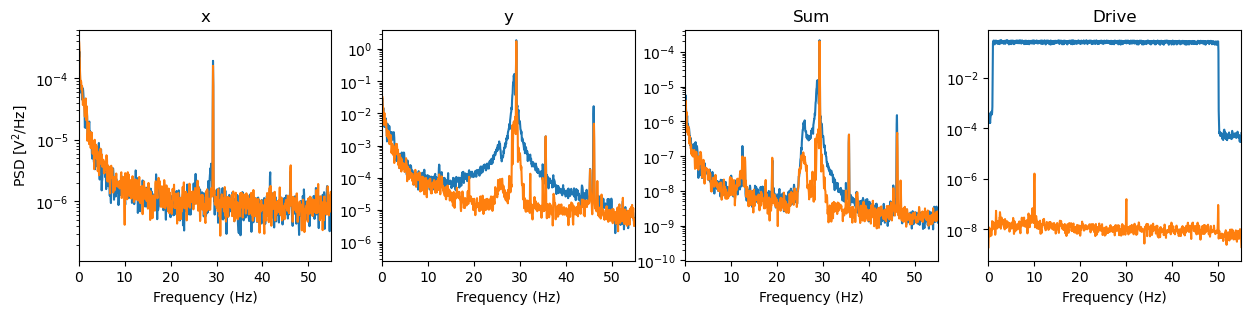

In [383]:
curr_psd_dict, curr_freqs = make_psd_from_file_list(curr_files)
ref_psd_dict, ref_freqs = make_psd_from_file_list(ref_files)

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)
plot_psd_dict(ref_psd_dict, ref_freqs, fig)

plt.show()

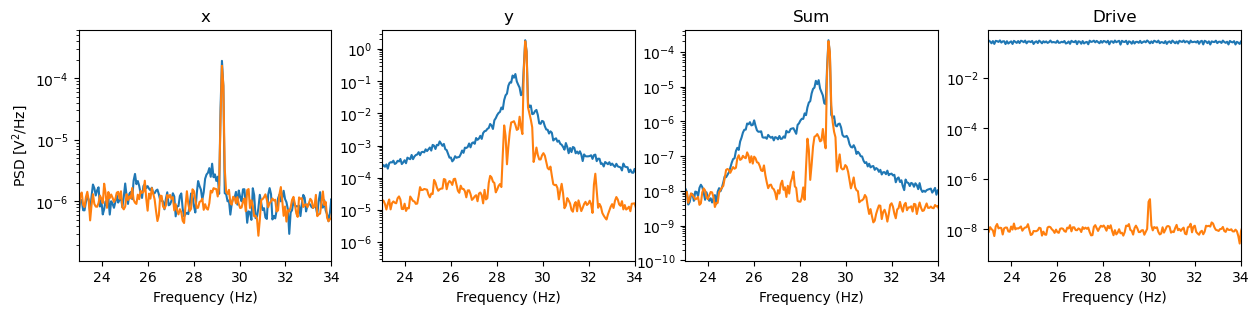

In [384]:
curr_psd_dict, curr_freqs = make_psd_from_file_list(curr_files)
ref_psd_dict, ref_freqs = make_psd_from_file_list(ref_files)

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)
plot_psd_dict(ref_psd_dict, ref_freqs, fig, xlims=[23,34])

plt.show()

In [684]:
### same as above, but make the sweep versus pressure with no reference

pressure_data_dir = "C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250317/"

pressure_files = glob(data_dir + "transfer_func_data_noise_0.*Hz_20.000V_*mbar.npz")

## write a regex to extract the pressure from the file name
pressure_list = []
for f in pressure_files:
    pressure_list.append(float(f.split("_")[-1].replace("mbar.npz", "")))

pressure_sort_idx = np.argsort(pressure_list)
pressure_files = np.array(pressure_files)[pressure_sort_idx]
pressure_list = np.array(pressure_list)[pressure_sort_idx]

print("Found %d pressure files with pressures:" % (len(pressure_files)))
print(pressure_list)

## get colormap in pressure order
n_colors = len(pressure_files)
colors = plt.cm.jet(np.linspace(0, 1, n_colors))

Found 45 pressure files with pressures:
[5.57e-07 1.01e-06 3.50e-06 1.33e-05 5.80e-05 9.21e-05 1.09e-04 1.25e-04
 1.68e-04 2.29e-04 3.22e-04 8.57e-04 1.16e-03 2.10e-03 2.64e-03 2.98e-03
 3.45e-03 3.95e-03 4.78e-03 5.34e-03 6.04e-03 6.52e-03 6.98e-03 7.37e-03
 7.96e-03 8.38e-03 9.69e-03 1.02e-02 1.09e-02 1.10e-02 2.54e-02 2.59e-02
 4.12e-02 5.58e-02 6.55e-02 7.54e-02 7.54e-02 9.07e-02 1.34e-01 3.22e-01
 4.84e-01 7.59e-01 9.91e-01 1.51e+00 2.26e+00]


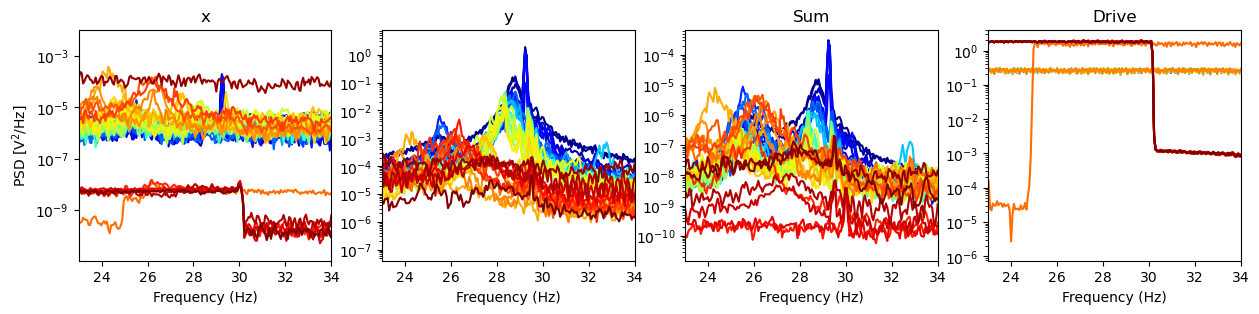

In [685]:
fig = plt.figure(figsize=(15,3))

nperseg = 2**14

for p, pf, c in zip(pressure_list, pressure_files, colors):
    curr_psd_dict, curr_freqs = make_psd_from_file_list([pf])
    if curr_psd_dict is None:
        continue
    plot_psd_dict(curr_psd_dict, curr_freqs, fig, xlims=[23,34], lc=c)

In [686]:
def lorentzianPSD(f, A, f0, gamma):
    omega = 2*np.pi*f
    omega0 = 2*np.pi*f0
    return A / ((omega**2-omega0**2)**2 + omega**2 * gamma**2)

In [692]:
def fit_psd(psd, freqs, fig=None, make_plot=False, ch='y', xlims=[0, 55], 
            lc=None, ylims=[1e-6,1], fit_range=[26, 31], noise_freqs=[], 
            subplot_idx = [], guess_params=[1e3, 29, 1], plot_guess=False,
            plot_label=""):

    """ Fit a lorentzian to the PSD data
        Args:
            psd: dict of psd data, with keys 'x', 'y', 'Sum', 'Drive'
            freqs: array of frequencies
            fig: figure to plot on
            make_plot: whether to plot the fit
            ch: channel to fit
            xlims: x limits for the plot
            lc: line color for the plot
            ylims: y limits for the plot
            fit_range: range of frequencies to fit
            noise_freqs: list of frequency ranges to exclude from the fit
            subplot_idx: index of the subplot to plot in
            guess_params: initial guess for the fit parameters  
            plot_guess: whether to plot the initial guess
            plot_label: label for the plot
        Returns:
            bp: array of fit parameters
    """

    bad_points = np.zeros(len(freqs), dtype=bool)
    if(len(noise_freqs) > 0):
        for nf in noise_freqs:
            bad_points = bad_points | ((freqs > nf[0]) & (freqs < nf[1]))

    ## fit lorentzian to the PSD
    fit_idx = ((freqs > fit_range[0]) & (freqs < fit_range[1])) & ~bad_points

    freq_vals = np.linspace(freqs[fit_idx][0], freqs[fit_idx][-1], 1000)

    if(not plot_guess):
        bp, bcov = curve_fit(lorentzianPSD, freqs[fit_idx], psd[ch][fit_idx], p0=guess_params, sigma=psd[ch][fit_idx])
    else:
        bp = guess_params

    if(make_plot):
        plt.figure(fig.number)
        ms=1

        if(len(subplot_idx) > 0):
            plt.subplot(subplot_idx[0], subplot_idx[1], subplot_idx[2])

        if(lc is not None):
            plt.semilogy(freqs, psd[ch], 'o', color=lc, markersize=ms)
            plt.semilogy(freq_vals, lorentzianPSD(freq_vals, *bp), color=lc, markersize=ms, label=plot_label)

            plt.semilogy(freqs[bad_points], psd[ch][bad_points], 'o', color='gray', markersize=ms)
        else:
            plt.semilogy(freqs, psd[ch], 'o', markersize=2)
            plt.semilogy(freq_vals, lorentzianPSD(freq_vals, *bp), markersize=ms, label=plot_label)
    

        plt.xlim(xlims[0], xlims[1])
        plt.ylim(ylims[0], ylims[1])
        if(len(plot_label) > 0):
            plt.legend()
    return bp

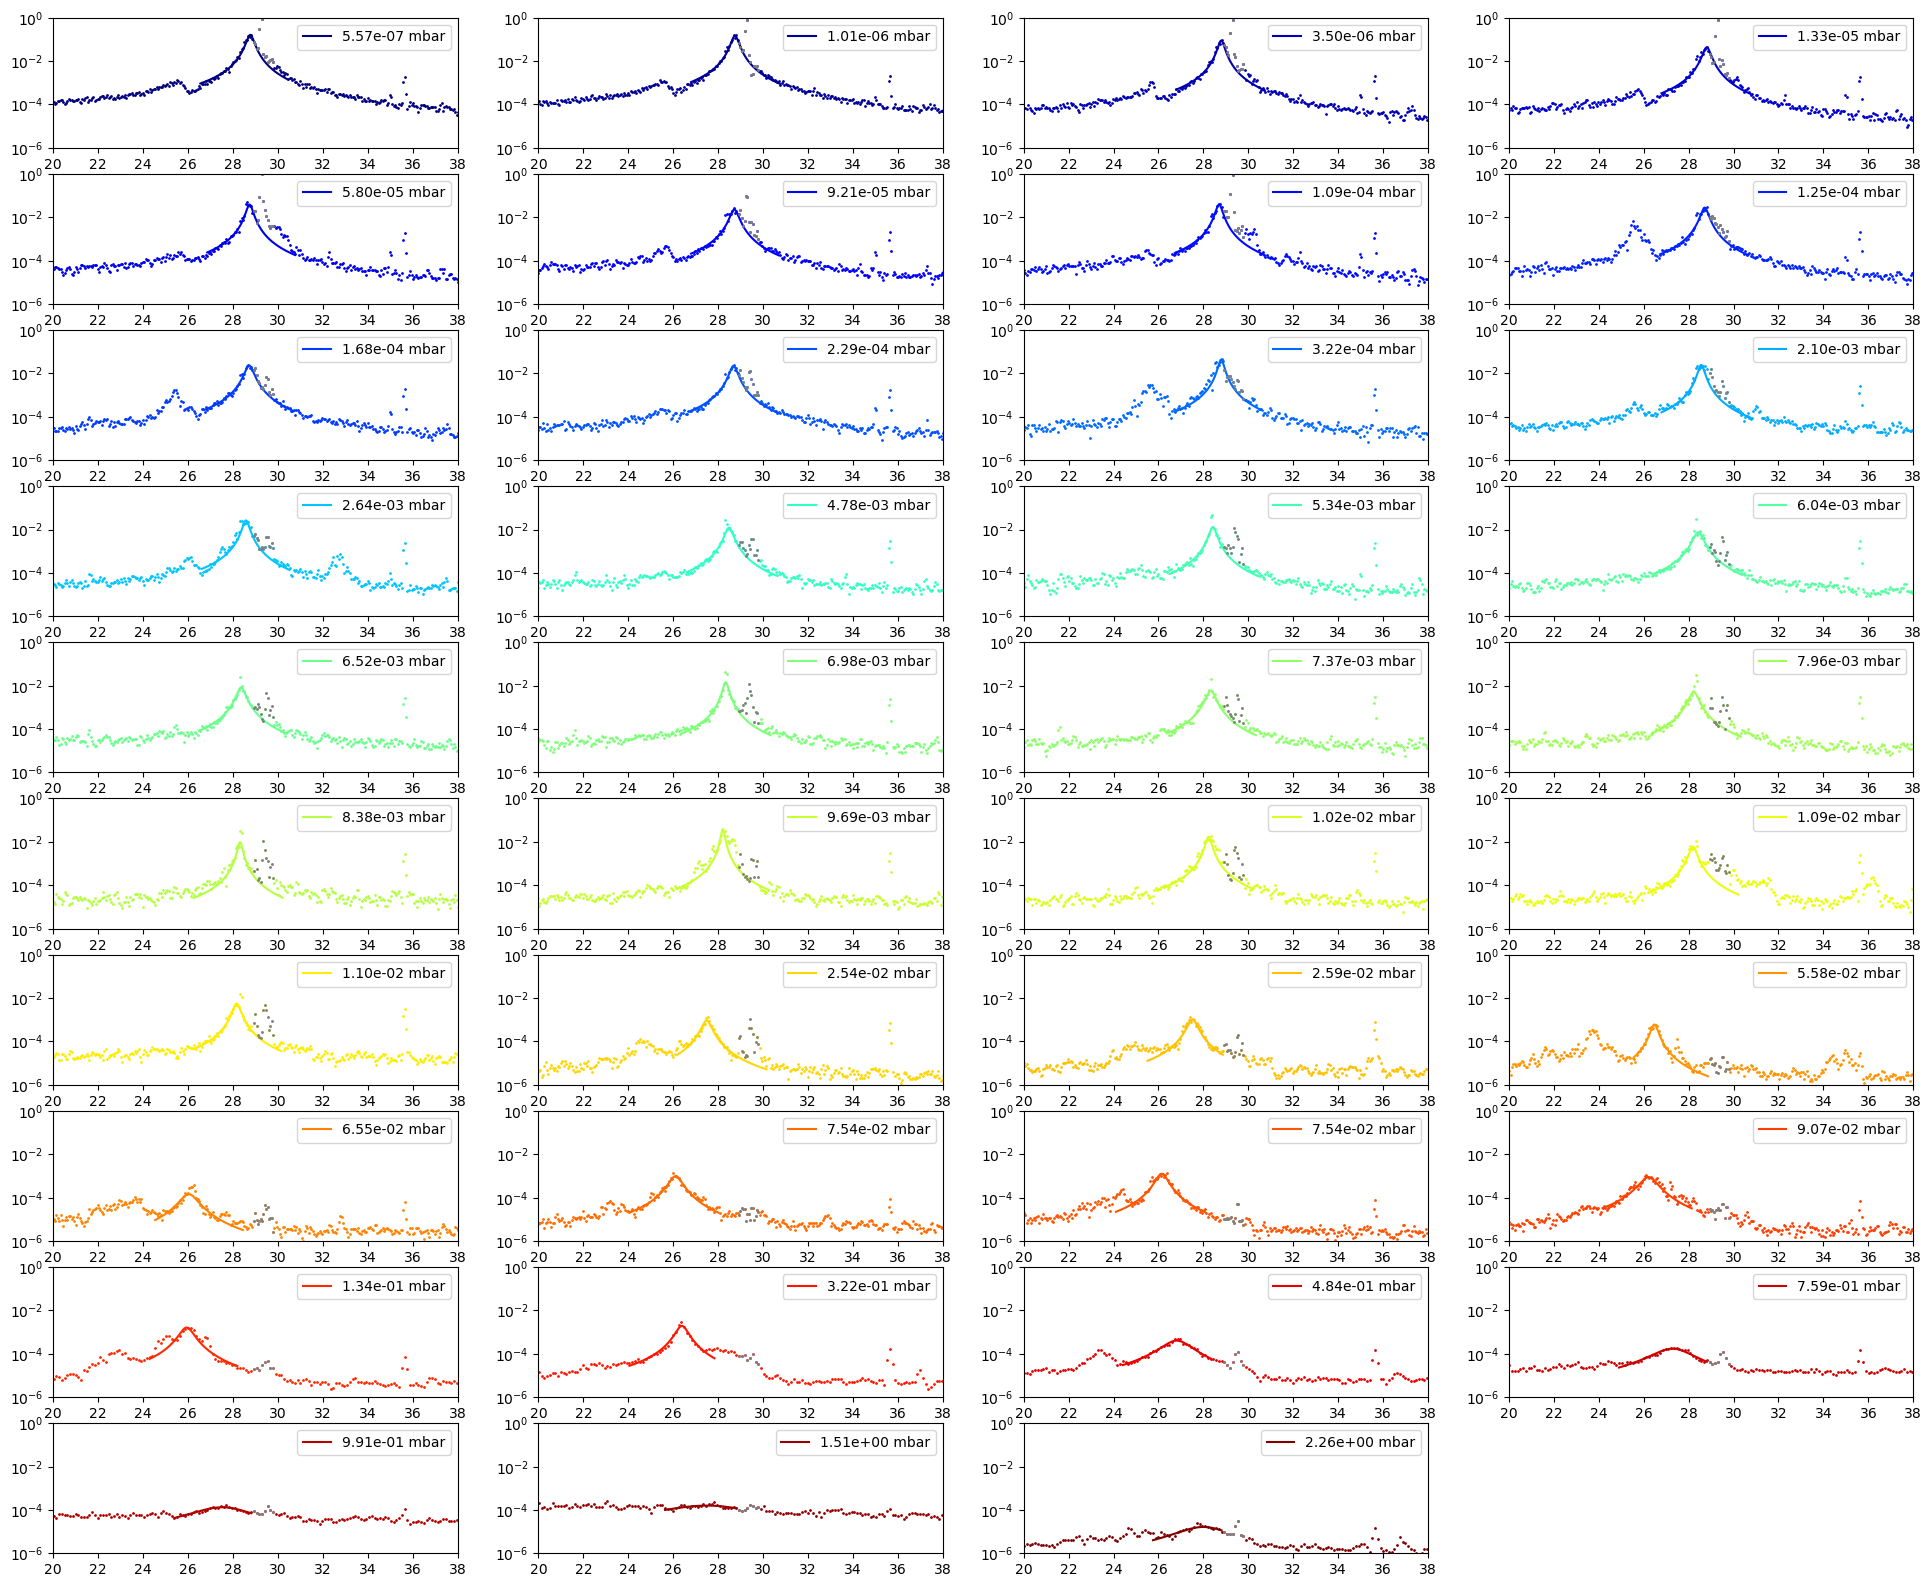

In [693]:
fig = plt.figure(figsize=(24,24))

noise_freqs = [[28.9,29.3],[29.3,29.8]] #freqs to exclude from the fit due to pump noise
bad_list= [4.12e-2]
plot_idx = 1
ncols = 4
nrows = int(len(pressure_files)/4) + 1
bp = None
for p, pf, c in zip(pressure_list, pressure_files, colors):
    if(p < 0.1):
        nperseg = 2**14
    else:
        nperseg = 2**13
    curr_psd_dict, curr_freqs = make_psd_from_file_list([pf])
    if curr_psd_dict is None or p in bad_list:
        continue

    ## set starting parameters for fit
    if bp is None:
        last_fit = [1e3, 29, 1]
        fit_range = [26.5, 30.5]
    else:
        last_fit = bp
        fit_range = [bp[1]-2, bp[1]+2]

    
    bp = fit_psd(curr_psd_dict, curr_freqs, fig, xlims=[20,38], make_plot=True, ch='y', lc=c, 
            fit_range = fit_range, noise_freqs=noise_freqs, subplot_idx=[nrows, ncols, plot_idx], 
            guess_params=last_fit, plot_guess=False, plot_label="%.2e mbar"%p)
    plot_idx += 1

# ## make a colorbar with the pressure values
# from matplotlib.colors import Normalize
# from matplotlib.cm import ScalarMappable
# from matplotlib.colorbar import ColorbarBase
# norm = Normalize(vmin=np.log10(pressure_list.min()), vmax=np.log10(pressure_list.max()))
# sm = ScalarMappable(cmap='jet', norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=fig.axes, orientation='vertical')
# cbar.set_label('Pressure (mbar)')
# ticks = np.log10(np.logspace(np.log10(pressure_list.min()), np.log10(pressure_list.max()), 8))
# cbar.set_ticks(ticks)
# cbar.set_ticklabels([f"{10**p:.1e}" for p in ticks])

plt.show()

In [689]:
data = np.load(pressure_files[-1])

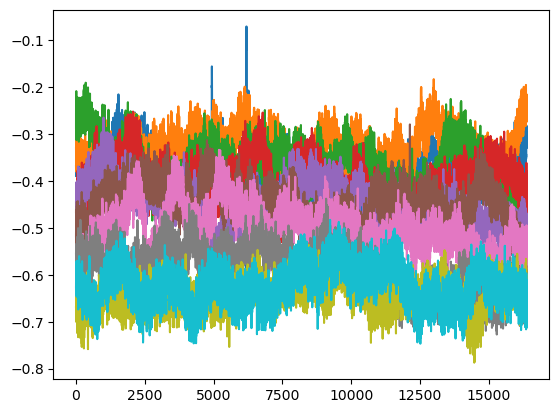

In [690]:
plt.figure()
plt.plot(data['data'][:,:,1].T)

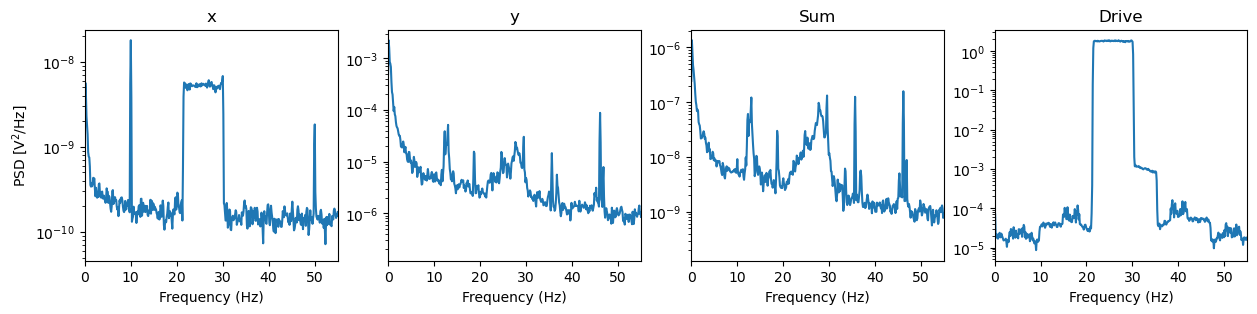

In [691]:
curr_psd_dict, curr_freqs = make_psd_from_file_list([pressure_files[-1]])

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)